In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [7]:
ticker_symbol = "^N225"
nikkei_data = yf.download(ticker_symbol, start="2005-10-11", end="2025-10-11")

[*********************100%***********************]  1 of 1 completed


In [8]:
nikkei_data = (nikkei_data.xs('^N225', axis=1, level=0)
              if '^N225' in nikkei_data.columns.get_level_values(0)
              else nikkei_data.xs('^N225', axis=1, level=1))


nikkei_data['Close'] = nikkei_data['Close'].astype(float)
nikkei_data['High'] = nikkei_data['Close'].astype(float)
nikkei_data['Low'] = nikkei_data['Close'].astype(float)

In [9]:
nikkei_data.head(3)

Price,Close,High,Low,Open,Volume
Date,,,,,
2005-10-11,13556.709961,13556.709961,13556.709961,13280.330078,170600000
2005-10-12,13463.740234,13463.740234,13463.740234,13565.870117,202100000
2005-10-13,13449.240234,13449.240234,13449.240234,13388.019531,134700000


In [10]:
nikkei_data.tail(3)

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-10-08,47734.988281,47734.988281,47734.988281,47925.218750,142200000
2025-10-09,48580.441406,48580.441406,48580.441406,48035.421875,138500000
2025-10-10,48088.800781,48088.800781,48088.800781,48510.718750,150700000


In [11]:
new_col = []
for i in range(1,nikkei_data.shape[0]):
    if nikkei_data['Close'].iloc[i] > nikkei_data['Close'].iloc[i-1]:
        new_col.append('up')
    elif nikkei_data['Close'].iloc[i] <= nikkei_data['Close'].iloc[i-1]:
        new_col.append('down')
    else:
        break
new_col.append('unknown')
nikkei_data['status'] = new_col
nikkei_data.tail()

Price,Close,High,Low,Open,Volume,status
Date,,,,,,
2025-10-06,47944.761719,47944.761719,47944.761719,46636.070312,178300000,up
2025-10-07,47950.878906,47950.878906,47950.878906,48281.121094,154200000,down
2025-10-08,47734.988281,47734.988281,47734.988281,47925.218750,142200000,up
2025-10-09,48580.441406,48580.441406,48580.441406,48035.421875,138500000,down
2025-10-10,48088.800781,48088.800781,48088.800781,48510.718750,150700000,unknown


In [12]:
period = 10
sharp_change_std_threshold = 2.0

nikkei_data['Daily_Pct_Change'] = nikkei_data['Close'].pct_change()
nikkei_data['Rolling_Std_Pct_Change'] = nikkei_data['Daily_Pct_Change'].rolling(window=period).std()
rolling_std_threshold = nikkei_data['Daily_Pct_Change'].std() * 2

nikkei_data['Is_Sharp_Volatility_Period'] = nikkei_data['Rolling_Std_Pct_Change'] > rolling_std_threshold


In [13]:
nikkei_data['RSI_14'] = ta.momentum.rsi(nikkei_data['Close'], window=14)

nikkei_data['SMA_10'] = ta.trend.sma_indicator(nikkei_data['Close'], window=10)
nikkei_data['SMA_50'] = ta.trend.sma_indicator(nikkei_data['Close'], window=50)

nikkei_data['SMA_10_vs_50_Ratio'] = (nikkei_data['SMA_10'] - nikkei_data['SMA_50']) / nikkei_data['Close']

nikkei_data['ATR_14'] = ta.volatility.average_true_range(
    nikkei_data['High'], nikkei_data['Low'], nikkei_data['Close'], window=14
)

nikkei_data['ATR_14_Normalized'] = nikkei_data['ATR_14'] / nikkei_data['Close']

In [14]:
df = nikkei_data.loc[nikkei_data['Is_Sharp_Volatility_Period']]

In [15]:
headlines = pd.read_csv('dataset.csv')
headlines = headlines.set_index(pd.to_datetime(headlines['date']))
headlines.drop('date', axis=1)
headlines['headlines'] = headlines['headlines'].astype(str)

In [16]:
df['Headlines'] = headlines['headlines']

In [17]:
from transformers import pipeline

analyzer = pipeline(
    "sentiment-analysis",
    model="koheiduck/bert-japanese-finetuned-sentiment",
    device=0
)
sentiments = []
for index, row in df.iterrows():
    model_output = analyzer(row['Headlines'])[0]
    sentiment = model_output['score']
    if model_output['label'] == 'POSITIVE':
        sentiment = 1.0
    elif model_output['label'] == 'NEUTRAL':
        sentiment = 0.6
    sentiments.append(sentiment)

df['sentiment_score'] = sentiments
df[['status','sentiment_score']].head()

Device set to use mps:0


Price,status,sentiment_score
Date,,
2008-01-25,down,0.600000
2008-01-28,up,0.568301
2008-01-29,down,0.600000
2008-01-30,up,0.715559
2008-01-31,down,0.600000


In [24]:
df.to_csv()

'Date,Close,High,Low,Open,Volume,status,Daily_Pct_Change,Rolling_Std_Pct_Change,Is_Sharp_Volatility_Period,RSI_14,SMA_10,SMA_50,SMA_10_vs_50_Ratio,ATR_14,ATR_14_Normalized,Headlines,sentiment_score\n2008-01-25,13629.16015625,13629.16015625,13629.16015625,13258.76953125,178800000,down,0.040967607460785205,0.03162719458687242,True,41.15284866104739,13468.266015625,14943.2549609375,-0.1082230253663947,279.77705195483014,0.020527827741941326,３カ月展望\u3000米国株、下値固めの展開か――政策への反応焦点に,0.6\n2008-01-28,13087.91015625,13087.91015625,13087.91015625,13482.83984375,152900000,up,-0.039712645078265996,0.033273281291509915,True,35.82204334160491,13365.97802734375,14889.5817578125,-0.11641306459772487,298.4536911009137,0.02280376985613629,ダボス会議閉幕、政策協調すれ違い――米国、財政出動を訴え,0.5683013200759888\n2008-01-29,13478.8603515625,13478.8603515625,13478.8603515625,13246.6904296875,147000000,down,0.029871094058955272,0.03521029913294295,True,41.69684470074933,13316.60107421875,14847.49056640625,-0.11357707196736672,305.060584

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

Classification Report
              precision    recall  f1-score   support

        down       0.53      0.60      0.56        68
          up       0.64      0.57      0.60        86

    accuracy                           0.58       154
   macro avg       0.59      0.59      0.58       154
weighted avg       0.59      0.58      0.59       154



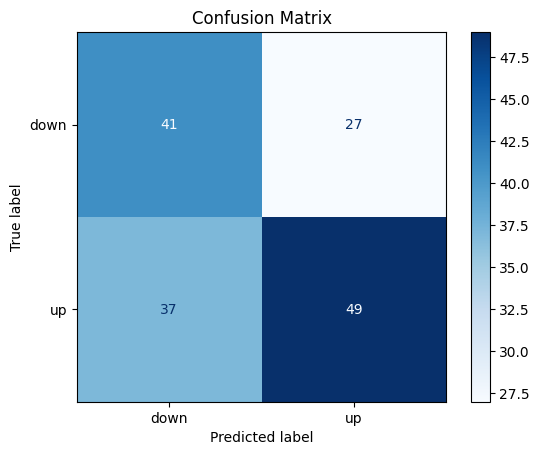

In [19]:
X = df[['RSI_14', 'SMA_10_vs_50_Ratio', 'ATR_14_Normalized', 'sentiment_score']]
y = df['status']

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X, y)

y_pred = model.predict(X)

print("Classification Report")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [20]:
random = [7, 19, 53, 514, 248, 590, 2025, 1204, 450, 976]

In [21]:
X = df[['RSI_14', 'SMA_10_vs_50_Ratio', 'ATR_14_Normalized', 'sentiment_score']]
y = df['status']
scores = []
for rand in random:
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=rand)

    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    score = accuracy_score(y_test, y_pred)
    scores.append(score)

print(f"平均精度 = {np.mean(scores)}")


平均精度 = 0.5838709677419356


Classification Report
              precision    recall  f1-score   support

        down       0.65      0.92      0.76        12
          up       0.93      0.68      0.79        19

    accuracy                           0.77        31
   macro avg       0.79      0.80      0.77        31
weighted avg       0.82      0.77      0.78        31



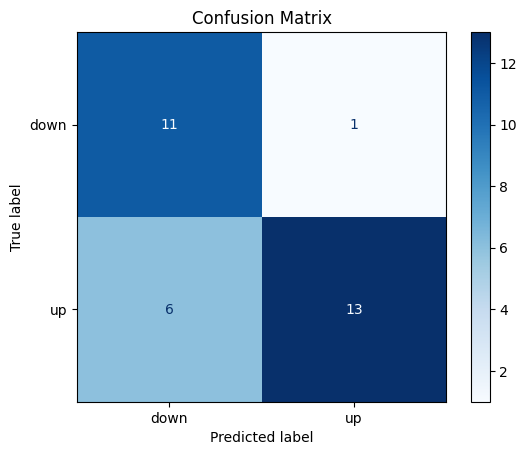

In [22]:
X = df[['RSI_14', 'SMA_10_vs_50_Ratio', 'ATR_14_Normalized', 'sentiment_score']]
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=7)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

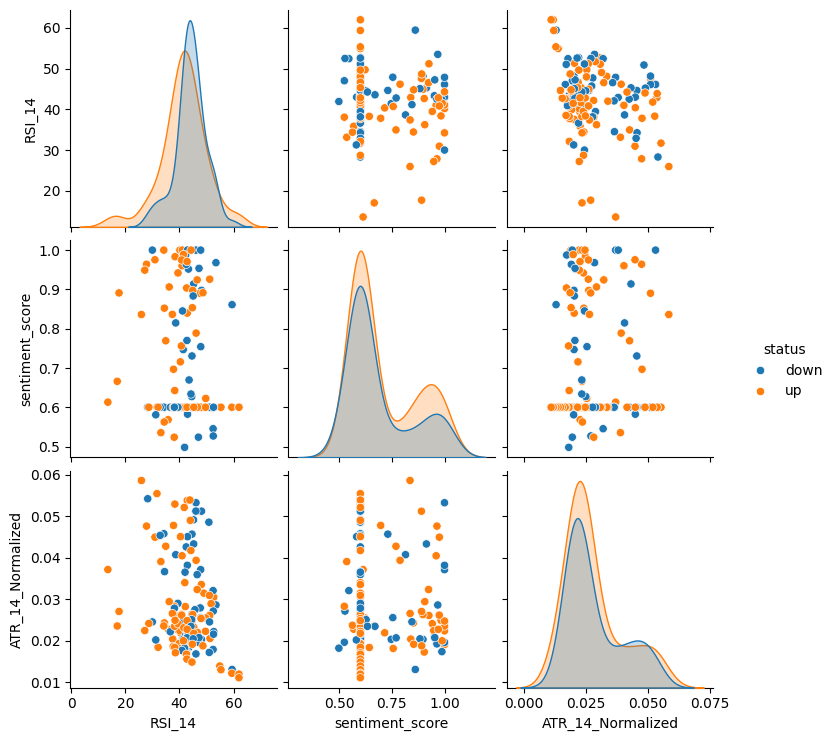

In [23]:
sns.pairplot(df, vars=['RSI_14', 'sentiment_score', 'ATR_14_Normalized'], hue='status', diag_kind='kde')
plt.show()